# Experiment 06 — PyTorch stacker on experiment 04 + 05 models

Frozen base models from the previous two experiments become meta-features. A **PyTorch** network learns how to combine them for **fraud F1**.

**Experiment 04 (sklearn, 80/20 `random_state=42` split)**  
`pred_dt` (balanced tree), `pred_knn`, `pred_rf`, and the F1 meta-RF `pred_meta_f1`.

**Experiment 05 (six nets)**  
`nn_f1_train`, `nn_f1_val`, `nn_recall_train`, `nn_recall_val`, `nn_precision_train`, `nn_precision_val`.

Install PyTorch first (next cell), then run the rest yourself.


In [10]:
%pip install -q torch


Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import tempfile
import time
import zipfile
from pathlib import Path

import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("PyTorch", torch.__version__)
print("device", device)


PyTorch 2.13.0
device mps


In [2]:
ROOT = Path("..")
DATA_DIR = ROOT / "_data"
MODEL_DIR = ROOT / "_models"
EXP05_DIR = Path("experiment05_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

META_FROM_EXP04 = ["pred_dt", "pred_knn", "pred_rf"]
NN_NAMES = [
    "nn_f1_train",
    "nn_f1_val",
    "nn_recall_train",
    "nn_recall_val",
    "nn_precision_train",
    "nn_precision_val",
]
META_COLS = META_FROM_EXP04 + ["pred_meta_f1"] + NN_NAMES

DT_PATH = MODEL_DIR / "dt_balanced_f1_2026_08_20_19_16_59.pkl"
STACK_F1_PATH = MODEL_DIR / "rf_stacking_f1_2026_08_20_19_16_59.pkl"
STACK_TRAIN_PATH = DATA_DIR / "stacking_train_data_exp04.csv"
STACK_TEST_PATH = DATA_DIR / "stacking_test_data_exp04.csv"
MANIFEST_PATH = EXP05_DIR / "manifest.json"


In [3]:
def predict_at_threshold(proba, threshold):
    return (np.asarray(proba).ravel() >= threshold).astype(int)


def metrics_at_threshold(y_true, proba, threshold):
    y_true = np.asarray(y_true).ravel()
    y_pred = predict_at_threshold(proba, threshold)
    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
        "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
    }


def threshold_sweep(y_true, proba, thresholds):
    return pd.DataFrame([metrics_at_threshold(y_true, proba, t) for t in thresholds]).sort_values("threshold")


def pick_threshold_for_f1(train_df):
    row = train_df.sort_values(["f1", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(row["threshold"]), row


def show_metrics(df, cols=None):
    view = df if cols is None else df[cols]
    print(view.round({
        "threshold": 2, "precision": 4, "recall": 4, "f1": 4, "f2": 4, "accuracy": 6,
    }).to_string(index=False))


def plot_report_and_cm(y_true, y_pred, title):
    class_labels = ["Legitimate", "Fraud"]
    report_dict = classification_report(
        y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0
    )
    accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    report_df["accuracy"] = accuracy
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(report_df[["precision", "recall", "f1-score", "support", "accuracy"]],
                annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
    axes[0].set_title(f"{title} Classification Report")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
    axes[1].set_title(f"{title} Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


## Data and experiment 04 split


In [4]:
df = pd.read_csv(DATA_DIR / "creditcard.csv", index_col=0)
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train = y_train.squeeze()
y_test = y_test.squeeze()

stack_train = pd.read_csv(STACK_TRAIN_PATH)
stack_test = pd.read_csv(STACK_TEST_PATH)
assert np.array_equal(stack_train["Class"].to_numpy(), y_train.to_numpy())
assert np.array_equal(stack_test["Class"].to_numpy(), y_test.to_numpy())

dt_balanced = joblib.load(DT_PATH)
meta_f1 = joblib.load(STACK_F1_PATH)
manifest = json.loads(MANIFEST_PATH.read_text())
print("Train", X_train.shape, "frauds", int(y_train.sum()))
print("Test ", X_test.shape, "frauds", int(y_test.sum()))
print("Exp04 DT:", type(dt_balanced).__name__)
print("Exp05 nets:", list(manifest["models"]))


Train (227845, 30) frauds 394
Test  (56962, 30) frauds 98
Exp04 DT: Pipeline
Exp05 nets: ['nn_f1_train', 'nn_f1_val', 'nn_recall_train', 'nn_recall_val', 'nn_precision_train', 'nn_precision_val']


## Experiment 04 scores

Train `pred_dt` / `pred_knn` / `pred_rf` are out-of-fold from experiment 04. `pred_meta_f1` is the experiment 04 Random Forest stacker.


In [5]:
meta_train = stack_train[META_FROM_EXP04].copy()
meta_test = stack_test[META_FROM_EXP04].copy()
meta_train["pred_meta_f1"] = meta_f1.predict_proba(stack_train[META_FROM_EXP04])[:, 1]
meta_test["pred_meta_f1"] = meta_f1.predict_proba(stack_test[META_FROM_EXP04])[:, 1]
print(meta_train.head())


   pred_dt  pred_knn  pred_rf  pred_meta_f1
0      0.0       0.0      0.0      0.000095
1      0.0       0.0      0.0      0.000095
2      0.0       0.0      0.0      0.000095
3      0.0       0.0      0.0      0.000095
4      0.0       0.0      0.0      0.000095


## Experiment 05 neural-net scores

Frozen experiment 05 weights are read from the `.keras` files with numpy (no TensorFlow). Dropout is off at inference.


In [6]:
def nn_feature_matrix(frame, amount_scaler, time_scaler):
    scaled_amount = amount_scaler.transform(frame[["Amount"]])
    scaled_time = time_scaler.transform(frame[["Time"]])
    v = frame[[f"V{i}" for i in range(1, 29)]].to_numpy(dtype=np.float32)
    return np.hstack([scaled_amount, scaled_time, v]).astype(np.float32)


def _h5_arr(f, path):
    return np.array(f[path][()], dtype=np.float32)


def load_exp05_keras(path):
    path = Path(path)
    with zipfile.ZipFile(path) as zf, tempfile.TemporaryDirectory() as td:
        zf.extract("model.weights.h5", td)
        with h5py.File(Path(td) / "model.weights.h5", "r") as f:
            dense = []
            for name in ["dense", "dense_1", "dense_2", "dense_3", "dense_4"]:
                dense.append((_h5_arr(f, f"layers/{name}/vars/0"),
                              _h5_arr(f, f"layers/{name}/vars/1")))
            bns = []
            for name in ["batch_normalization", "batch_normalization_1", "batch_normalization_2"]:
                gamma = _h5_arr(f, f"layers/{name}/vars/0")
                beta = _h5_arr(f, f"layers/{name}/vars/1")
                mean = _h5_arr(f, f"layers/{name}/vars/2")
                var = _h5_arr(f, f"layers/{name}/vars/3")
                bns.append((gamma, beta, mean, var))

    def _bn(x, params, eps=1e-3):
        gamma, beta, mean, var = params
        return gamma * (x - mean) / np.sqrt(var + eps) + beta

    def predict_proba(X, batch_size=8192):
        X = np.asarray(X, dtype=np.float32)
        out = np.empty(len(X), dtype=np.float32)
        for i in range(0, len(X), batch_size):
            h = X[i:i + batch_size]
            h = np.maximum(h @ dense[0][0] + dense[0][1], 0)
            h = _bn(h, bns[0])
            h = np.maximum(h @ dense[1][0] + dense[1][1], 0)
            h = _bn(h, bns[1])
            h = np.maximum(h @ dense[2][0] + dense[2][1], 0)
            h = _bn(h, bns[2])
            h = np.maximum(h @ dense[3][0] + dense[3][1], 0)
            logits = h @ dense[4][0] + dense[4][1]
            out[i:i + batch_size] = (1.0 / (1.0 + np.exp(-np.clip(logits.ravel(), -80, 80))))
        return out

    return predict_proba


amount_scaler = RobustScaler().fit(df[["Amount"]])
time_scaler = RobustScaler().fit(df[["Time"]])
Xnn_train = nn_feature_matrix(X_train, amount_scaler, time_scaler)
Xnn_test = nn_feature_matrix(X_test, amount_scaler, time_scaler)
print("NN feature matrix", Xnn_train.shape, Xnn_test.shape)

for name in NN_NAMES:
    predict_fn = load_exp05_keras(EXP05_DIR / f"{name}.keras")
    meta_train[name] = predict_fn(Xnn_train)
    meta_test[name] = predict_fn(Xnn_test)
    print(name, "train mean", float(meta_train[name].mean()), "test mean", float(meta_test[name].mean()))


NN feature matrix (227845, 30) (56962, 30)
nn_f1_train train mean 0.0016742434818297625 test mean 0.001856726361438632
nn_f1_val train mean 0.0016577595379203558 test mean 0.0018384847790002823
nn_recall_train train mean 0.004484210163354874 test mean 0.004531817976385355
nn_recall_val train mean 0.004586092196404934 test mean 0.004559019114822149
nn_precision_train train mean 0.0016328003257513046 test mean 0.0017729512182995677
nn_precision_val train mean 0.0016787316417321563 test mean 0.0017848361749202013


## PyTorch meta-model

Input is the 10 frozen scores: **64 → 32 → 1**. No class weighting. A stratified slice of the experiment 04 train fold is validation; the real test fold stays locked until after training.


In [7]:
class StackerNet(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def predict_proba_torch(model, X, batch_size=2048):
    model.eval()
    X_t = torch.tensor(np.asarray(X, dtype=np.float32), device=device)
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            logits = model(X_t[i:i + batch_size])
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs, axis=0)


X_meta_train = meta_train[META_COLS].to_numpy(dtype=np.float32)
X_meta_test = meta_test[META_COLS].to_numpy(dtype=np.float32)
y_meta_train = y_train.to_numpy().astype(np.float32)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_meta_train, y_meta_train, test_size=0.2, random_state=42, stratify=y_meta_train
)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_fit), torch.tensor(y_fit)),
    batch_size=512,
    shuffle=True,
)
val_X = torch.tensor(X_val, device=device)
val_y = torch.tensor(y_val, device=device)

stacker = StackerNet(X_fit.shape[1]).to(device)
print(stacker)
optimizer = torch.optim.Adam(stacker.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
loss_fn = nn.BCEWithLogitsLoss()

ckpt_path = MODEL_DIR / "pytorch_stacking_exp06.pt"
best_val = float("inf")
wait = 0
patience = 8
epochs = 40

for epoch in range(1, epochs + 1):
    stacker.train()
    train_loss = 0.0
    n_seen = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(stacker(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += float(loss.item()) * len(xb)
        n_seen += len(xb)
    train_loss /= n_seen

    stacker.eval()
    with torch.no_grad():
        val_loss = float(loss_fn(stacker(val_X), val_y).item())
    scheduler.step(val_loss)
    print(f"epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.1e}")

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        wait = 0
        torch.save({"model": stacker.state_dict(), "n_inputs": X_fit.shape[1]}, ckpt_path)
        print("  saved", ckpt_path)
    else:
        wait += 1
        if wait >= patience:
            print("early stop")
            break

ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
stacker.load_state_dict(ckpt["model"])
print("Loaded best checkpoint", ckpt_path)


StackerNet(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=32, out_features=1, bias=True)
  )
)
epoch 01  train_loss=0.0865  val_loss=0.0023  lr=1.0e-03
  saved ../_models/pytorch_stacking_exp06.pt
epoch 02  train_loss=0.0036  val_loss=0.0014  lr=1.0e-03
  saved ../_models/pytorch_stacking_exp06.pt
epoch 03  train_loss=0.0030  val_loss=0.0013  lr=1.0e-03
  saved ../_models/pytorch_stacking_exp06.pt
epoch 04  train_loss=0.0023  val_loss=0.0012  lr=1.0e-03
  saved ../_models/pytorch_stacking_exp06.pt
epoch 05  train_loss=0.0020  val_loss=0.0012  lr=1.0e-03
  saved ../_models/pytorch_stacking_exp06.pt
epoch 06  train_loss=0.0021  val_loss=0.0010  lr=1.0e-03
  sav

In [8]:
proba_train = predict_proba_torch(stacker, X_meta_train)
proba_test = predict_proba_torch(stacker, X_meta_test)

candidate_thresholds = np.unique(np.round(np.concatenate([
    np.linspace(0.05, 0.95, 91),
    [0.25, 0.3, 0.5, 0.7],
]), 4))
train_sweep = threshold_sweep(y_train, proba_train, candidate_thresholds)
best_t, best_row = pick_threshold_for_f1(train_sweep)
print(
    f"Selected t={best_t:.2f} (max train fraud F1={best_row['f1']:.4f}, "
    f"P={best_row['precision']:.4f}, R={best_row['recall']:.4f})"
)


Selected t=0.33 (max train fraud F1=0.9450, P=0.9757, R=0.9162)


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.91      0.95      0.93        98

    accuracy                           1.00     56962
   macro avg       0.96      0.97      0.96     56962
weighted avg       1.00      1.00      1.00     56962



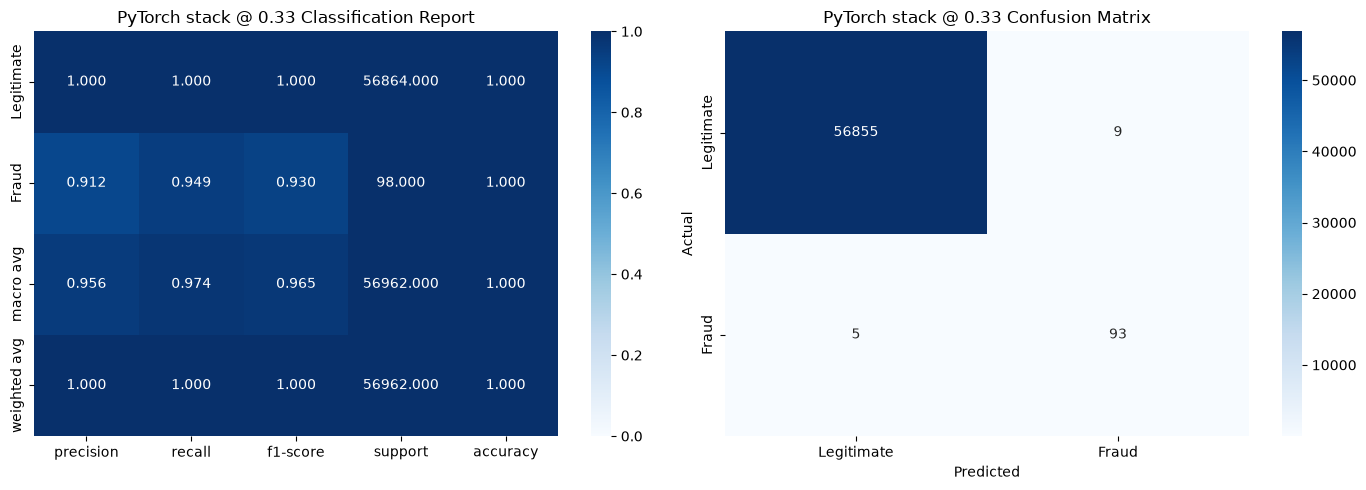

Test comparison
                   setting  threshold  precision  recall     f1  tp  fn   fp
   exp03 stacker F2 @ 0.25       0.25     0.8333  0.8673 0.8500  85  13   17
   exp03 stacker F1 @ 0.40       0.40     0.9000  0.8265 0.8617  81  17    9
      exp04 pred_dt @ 0.50       0.50     0.0374  0.8571 0.0717  84  14 2160
     exp04 pred_knn @ 0.50       0.50     0.9101  0.8265 0.8663  81  17    8
      exp04 pred_rf @ 0.50       0.50     0.8462  0.7857 0.8148  77  21   14
      exp04 meta RF @ 0.30       0.30     0.8557  0.8469 0.8513  83  15   14
        nn_f1_train @ 0.95       0.95     0.9286  0.9286 0.9286  91   7    7
          nn_f1_val @ 0.91       0.91     0.9109  0.9388 0.9246  92   6    9
    nn_recall_train @ 0.05       0.05     0.2125  0.9694 0.3486  95   3  352
      nn_recall_val @ 0.05       0.05     0.2289  0.9694 0.3704  95   3  320
 nn_precision_train @ 0.90       0.90     0.9286  0.9286 0.9286  91   7    7
   nn_precision_val @ 0.80       0.80     0.9192  0.9286 0.9

In [9]:
y_pred = predict_at_threshold(proba_test, best_t)
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], zero_division=0))
plot_report_and_cm(y_test, y_pred, f"PyTorch stack @ {best_t:.2f}")

old_stack_test = pd.read_csv(DATA_DIR / "stacking_test_data.csv")
old_stacker = joblib.load(MODEL_DIR / "rf_stacking_search_result_2026_08_20_17_30_45.pkl")
old_proba_test = old_stacker.predict_proba(old_stack_test[META_FROM_EXP04])[:, 1]

torch_test = metrics_at_threshold(y_test, proba_test, best_t)
rows = [
    {**metrics_at_threshold(y_test, old_proba_test, 0.25), "setting": "exp03 stacker F2 @ 0.25"},
    {**metrics_at_threshold(y_test, old_proba_test, 0.40), "setting": "exp03 stacker F1 @ 0.40"},
    {**metrics_at_threshold(y_test, meta_test["pred_dt"], 0.5), "setting": "exp04 pred_dt @ 0.50"},
    {**metrics_at_threshold(y_test, meta_test["pred_knn"], 0.5), "setting": "exp04 pred_knn @ 0.50"},
    {**metrics_at_threshold(y_test, meta_test["pred_rf"], 0.5), "setting": "exp04 pred_rf @ 0.50"},
    {**metrics_at_threshold(y_test, meta_test["pred_meta_f1"], 0.30), "setting": "exp04 meta RF @ 0.30"},
]
for name in NN_NAMES:
    t_lock = float(manifest["models"][name]["locked_threshold"])
    rows.append({
        **metrics_at_threshold(y_test, meta_test[name], t_lock),
        "setting": f"{name} @ {t_lock:.2f}",
    })
rows.append({**torch_test, "setting": f"exp06 PyTorch stack @ {best_t:.2f}"})
compare = pd.DataFrame(rows)
print("Test comparison")
show_metrics(compare[["setting", "threshold", "precision", "recall", "f1", "tp", "fn", "fp"]])


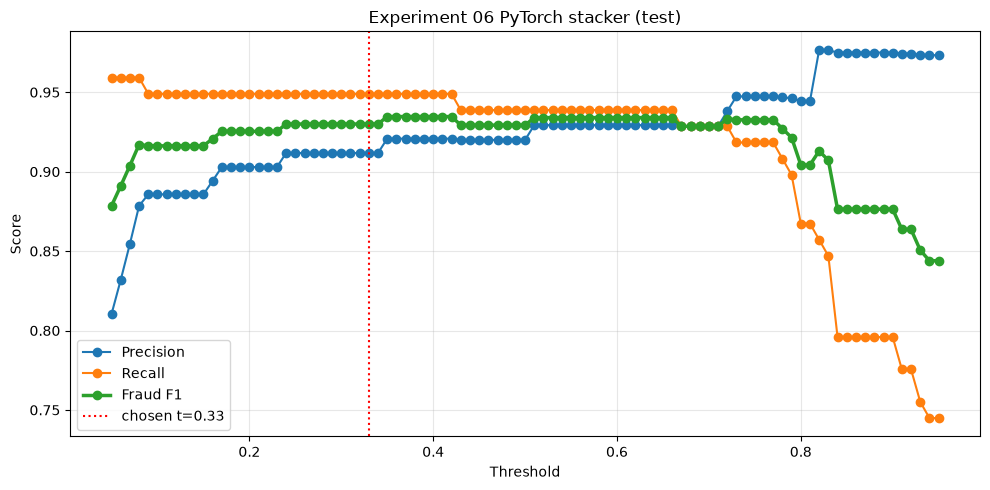

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
test_sweep = threshold_sweep(y_test, proba_test, candidate_thresholds)
ax.plot(test_sweep["threshold"], test_sweep["precision"], marker="o", label="Precision")
ax.plot(test_sweep["threshold"], test_sweep["recall"], marker="o", label="Recall")
ax.plot(test_sweep["threshold"], test_sweep["f1"], marker="o", linewidth=2.5, label="Fraud F1")
ax.axvline(best_t, color="red", linestyle=":", label=f"chosen t={best_t:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Experiment 06 PyTorch stacker (test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Save stacker and meta-features


In [11]:
stamp = time.strftime("%Y_%m_%d_%H_%M_%S")
save_path = MODEL_DIR / f"pytorch_stacking_exp06_{stamp}.pt"
torch.save({"model": stacker.state_dict(), "n_inputs": X_fit.shape[1], "threshold": float(best_t)}, save_path)

out_train = meta_train[META_COLS].copy()
out_train["pred_torch"] = proba_train
out_train["Class"] = y_train.to_numpy()
out_test = meta_test[META_COLS].copy()
out_test["pred_torch"] = proba_test
out_test["Class"] = y_test.to_numpy()
out_train.to_csv(DATA_DIR / "stacking_train_data_exp06.csv", index=False)
out_test.to_csv(DATA_DIR / "stacking_test_data_exp06.csv", index=False)

meta_info = {
    "model": str(save_path),
    "checkpoint": str(ckpt_path),
    "threshold": float(best_t),
    "meta_columns": META_COLS,
    "test": torch_test,
}
(MODEL_DIR / f"pytorch_stacking_exp06_{stamp}_meta.json").write_text(json.dumps(meta_info, indent=2))
print("Saved", save_path)
print("Saved stacking_train/test_data_exp06.csv")


Saved ../_models/pytorch_stacking_exp06_2026_08_20_21_26_13.pt
Saved stacking_train/test_data_exp06.csv
